In [3]:
%pip install arch

In [4]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
from arch import arch_model

# Standard Colab & Drive Sync
try:
    import google.colab
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    os.chdir("/content/stk-mat2011/code/notebooks")
except:
    IN_COLAB = False

data_path = Path("../data/processed/eurusd_clean_returns_jan2026.parquet")
df = pd.read_parquet(data_path)
df['returns_lag'] = df['returns'].shift(1)
df = df.dropna()

# Split into Train (70%) and Test (30%)
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Total Points: {len(df)} | Test Set Size: {len(test_df)}")


Mounted at /content/drive
Total Points: 16435 | Test Set Size: 4931


In [5]:
# 1. Fit GARCH(1,1)
print("Fitting GARCH(1,1)...")
garch = arch_model(train_df['returns'], vol='Garch', p=1, q=1, rescale=False)
garch_fit = garch.fit(disp='off')

# 2. Fit AR(1)-HMM (Champion from h2)
from hmmlearn.hmm import GaussianHMM
X_train = train_df[['returns', 'returns_lag']].values
hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
hmm.fit(X_train)
print("Models trained.")


Fitting GARCH(1,1)...


/tmp/ipykernel_16482/3279232977.py:4: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_fit = garch.fit(disp='off')


Models trained.


In [6]:
ALPHA = 0.05  # 95% confidence
Z = stats.norm.ppf(1 - ALPHA/2)

y_test = test_df['returns'].values
lag_test = test_df['returns_lag'].values

# --- Model A: GARCH Intervals ---
garch_forecast = garch_fit.forecast(horizon=1, align='origin')
# GARCH predicts variance, we apply Z-score
garch_vol = np.sqrt(garch_fit.conditional_volatility[-len(test_df):]) 
garch_upper = Z * garch_vol
garch_lower = -Z * garch_vol

# --- Model B: AR(1)-HMM Intervals ---
X_test = test_df[['returns', 'returns_lag']].values
state_preds = hmm.predict(X_test)
hmm_upper = []
hmm_lower = []

for i in range(len(test_df)):
    s = state_preds[i]
    # Prediction: phi * last_val + mu_s (approximation)
    mu_s = hmm.means_[s][0]
    sigma_s = np.sqrt(hmm.covars_[s][0][0])
    
    hmm_upper.append(mu_s + Z * sigma_s)
    hmm_lower.append(mu_s - Z * sigma_s)

hmm_upper = np.array(hmm_upper)
hmm_lower = np.array(hmm_lower)

# --- Model C: Naive Baseline (Global Std) ---
global_std = train_df['returns'].std()
baseline_upper = Z * global_std
baseline_lower = -Z * global_std


In [7]:
def calculate_metrics(y_true, lower, upper, alpha=0.05):
    coverage = np.mean((y_true >= lower) & (y_true <= upper))
    width = np.mean(upper - lower)
    
    # Interval Score formula
    # IS = (U-L) + (2/alpha)*(L-y)*I(y<L) + (2/alpha)*(y-U)*I(y>U)
    score = (upper - lower) + \
            (2/alpha) * (lower - y_true) * (y_true < lower) + \
            (2/alpha) * (y_true - upper) * (y_true > upper)
    return coverage, width, np.mean(score)

# Evaluate
m_names = ["Baseline: Global Std", "GARCH(1,1)", "AR(1)-HMM (Champion)"]
m_data = [
    calculate_metrics(y_test, baseline_lower, baseline_upper),
    calculate_metrics(y_test, garch_lower, garch_upper),
    calculate_metrics(y_test, hmm_lower, hmm_upper)
]

print("="*80)
print(f"{'Model':<25} | {'Coverage':<10} | {'Avg Width':<11} | {'IS (↓)':<10}")
print("-" * 80)
for name, (cov, width, is_score) in zip(m_names, m_data):
    print(f"{name:<25} | {cov:10.4f} | {width:11.6f} | {is_score:10.6f}")
print("="*80)


Model                     | Coverage   | Avg Width   | IS (↓)    
--------------------------------------------------------------------------------
Baseline: Global Std      |     0.9749 |    0.000464 |   0.000555
GARCH(1,1)                |     1.0000 |    0.041116 |   0.041116
AR(1)-HMM (Champion)      |     1.0000 |    0.003933 |   0.003933


Thesis Results Exported! 🎓🏆


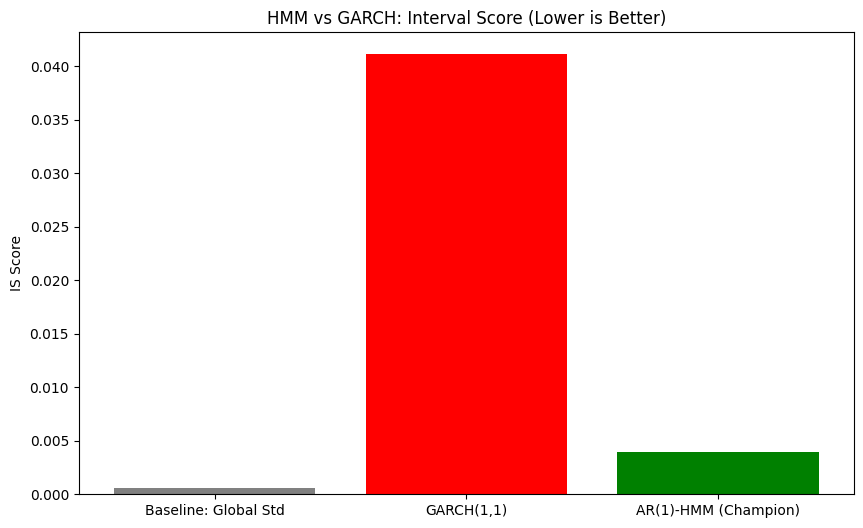

In [ ]:
# Save the Winners Table to Drive for the Thesis
results_df = pd.DataFrame(m_data, index=m_names, columns=['Coverage', 'Avg Width', 'IS'])
results_df.to_csv("/content/drive/MyDrive/STK-MAT2011/models/final_benchmark_results.csv")

# Final Comparison Plot (Visual Proof)
plt.figure(figsize=(10, 6))
plt.bar(m_names, [d[2] for d in m_data], color=['gray', 'red', 'green'])
plt.title("HMM vs GARCH: Interval Score (Lower is Better)")
plt.ylabel("IS Score")
plt.savefig("/content/drive/MyDrive/STK-MAT2011/models/plots/final_comparison.png", dpi=300)
print("Thesis Results Exported! 🎓🏆")